# Expected Goals -- Shot Characteristics

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [21]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

from src.data.split_data import train_test_split_by_match
from src.visualization.plot_xg_surface import plot_xg_surface
from src.visualization.plot_calibration import plot_calibration
from src.visualization.plot_shot_map import plot_shot_map

In [3]:
df = pd.read_csv("../../data/processed/shots.csv")

In [4]:
df["distance"] = np.sqrt(
    (120 - df["x"])**2 +
    (40 - df["y"])**2
)

In [5]:
goalpost_near = np.array([120, 36])
goalpost_far = np.array([120, 44])

shot_locations = df[["x", "y"]].values

vector_a = goalpost_near - shot_locations
vector_b = goalpost_far - shot_locations

dot_product = np.sum(vector_a * vector_b, axis=1)

magnitude_a = np.linalg.norm(vector_a, axis=1)
magnitude_b = np.linalg.norm(vector_b, axis=1)

cos_angle = dot_product / (magnitude_a * magnitude_b)
cos_angle = np.clip(cos_angle, -1, 1)

df["angle"] = np.arccos(cos_angle)

## Model 4 -- add shot characteristics

For model 4 we add information that describes how the shot was taken, but not contextual information from the preceding action yet.

We'll add:

body part, technique, shot type, first time, one on one, aerial_won

And retain:

distance, angle, the nonlinear terms from model 3

In [6]:
numerical_features = [
    "distance",
    "angle"
]

categorical_features = [
    "body_part",
    "technique",
    "shot_type",
    "first_time",
    "one_on_one",
    "aerial_won"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [8]:
model_shot_characteristics = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [9]:
train, test = train_test_split_by_match(
    df,
    test_size=0.2,
    random_state=42
)

In [10]:
features = numerical_features + categorical_features

X_train = train[features]
y_train = train["goal"]

X_test = test[features]
y_test = test["goal"]

In [11]:
model_shot_characteristics.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', 'passthrough',
                                                  ['distance', 'angle']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['body_part', 'technique',
                                                   'shot_type', 'first_time',
                                                   'one_on_one',
                                                   'aerial_won'])])),
                ('logistic', LogisticRegression(max_iter=1000))])

In [12]:
test["xg_shot_characteristics"] = (
    model_shot_characteristics
    .predict_proba(X_test)[:, 1]
)

In [13]:
logloss_shot_characteristics = log_loss(
    y_test,
    test["xg_shot_characteristics"]
)

brier_shot_characteristics = brier_score_loss(
    y_test,
    test["xg_shot_characteristics"]
)

auc_shot_characteristics = roc_auc_score(
    y_test,
    test["xg_shot_characteristics"]
)

print(
    f"Log Loss:    {logloss_shot_characteristics:.4f}"
)

print(
    f"Brier Score: {brier_shot_characteristics:.4f}"
)

print(
    f"ROC AUC:     {auc_shot_characteristics:.4f}"
)

Log Loss:    0.2442
Brier Score: 0.0677
ROC AUC:     0.7948


## Model Comparison

| Model | Log Loss | Brier Score | ROC AUC |
|---|---:|---:|---:|
| Constant probability | 0.2967 | 0.0796 | 0.5000 |
| Distance | 0.2667 | 0.0750 | 0.7398 |
| Distance + Angle | 0.2660 | 0.0746 | 0.7473 |
| Nonlinear Spatial | 0.2632 | 0.0739 | 0.7537 |
| Shot Characteristics | 0.2442 | 0.0677 | 0.7948 |

The improvement makes football sense: where a shot is taken isn't enough; how it is taken matters substantially.

## Visualization

In [14]:
def predict_shot_characteristics_xg(x, y):

    distance = np.sqrt(
        (120 - x)**2 +
        (40 - y)**2
    )

    shot_locations = np.column_stack((x, y))

    goalpost_near = np.array([120, 36])
    goalpost_far = np.array([120, 44])

    vector_a = goalpost_near - shot_locations
    vector_b = goalpost_far - shot_locations

    dot_product = np.sum(vector_a * vector_b, axis=1)

    magnitude_a = np.linalg.norm(vector_a, axis=1)
    magnitude_b = np.linalg.norm(vector_b, axis=1)

    cos_angle = dot_product / (
        magnitude_a * magnitude_b
    )

    cos_angle = np.clip(cos_angle, -1, 1)

    angle = np.arccos(cos_angle)

    X = pd.DataFrame({
        "distance": distance,
        "angle": angle,
        "body_part": "Right Foot",
        "technique": "Normal",
        "shot_type": "Open Play",
        "first_time": False,
        "one_on_one": False,
        "aerial_won": False
    })

    return model_shot_characteristics.predict_proba(X)[:, 1]

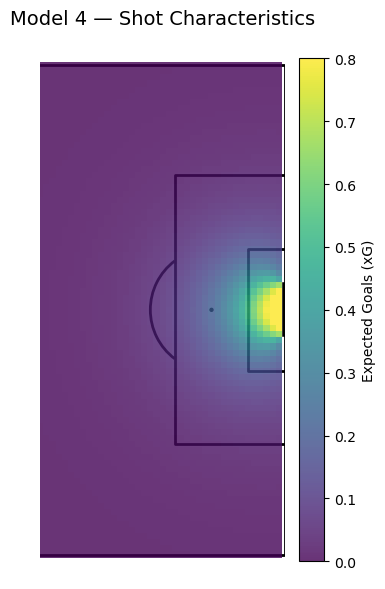

In [16]:
fig, ax = plot_xg_surface(
    predict_shot_characteristics_xg,
    title="Model 4 — Shot Characteristics",
    save_path="../../reports/figures/xg_surfaces/model_4_shot_characteristics.png"
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Calibration — Model 4 — Shot Characteristics'}, xlabel='Predicted xG', ylabel='Observed Goal Rate'>)

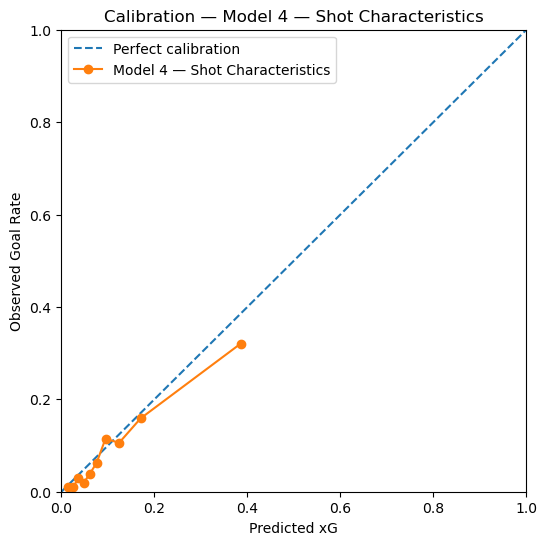

In [20]:
plot_calibration(
    y_test,
    test["xg_shot_characteristics"],
    model_name="Model 4 — Shot Characteristics",
    save_path="../../reports/figures/calibration/model_4_calibration.png"
)

### Shot maps

(<Figure size 800x1000 with 1 Axes>,
 <Axes: title={'center': 'Premier League 2015/16 — Model 4 xG'}>)

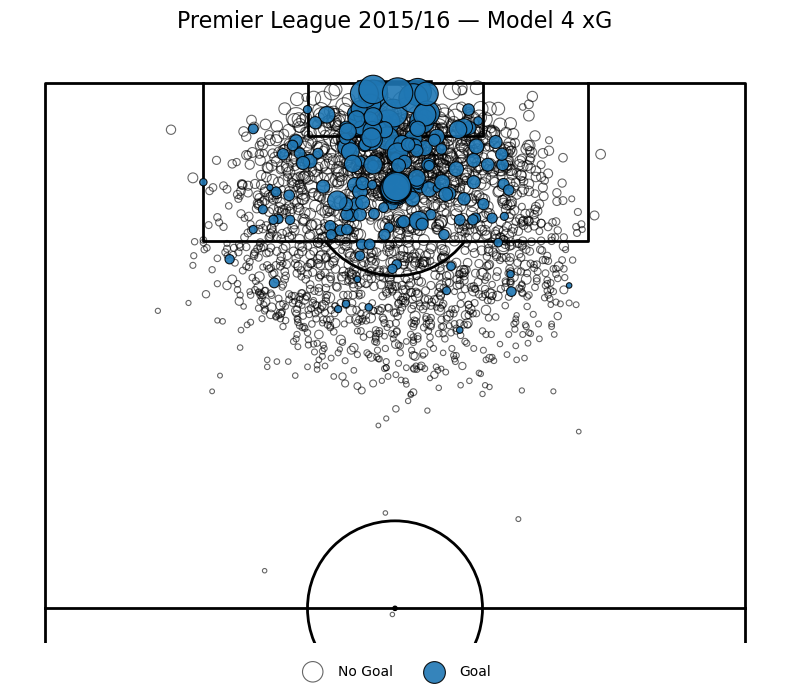

In [22]:
plot_shot_map(
    test,
    xg_column="xg_shot_characteristics",
    title="Premier League 2015/16 — Model 4 xG",
    save_path="../../reports/figures/model_4_shot_map.png"
)

(<Figure size 800x1000 with 1 Axes>,
 <Axes: title={'center': 'Arsenal — Model 4 xG'}>)

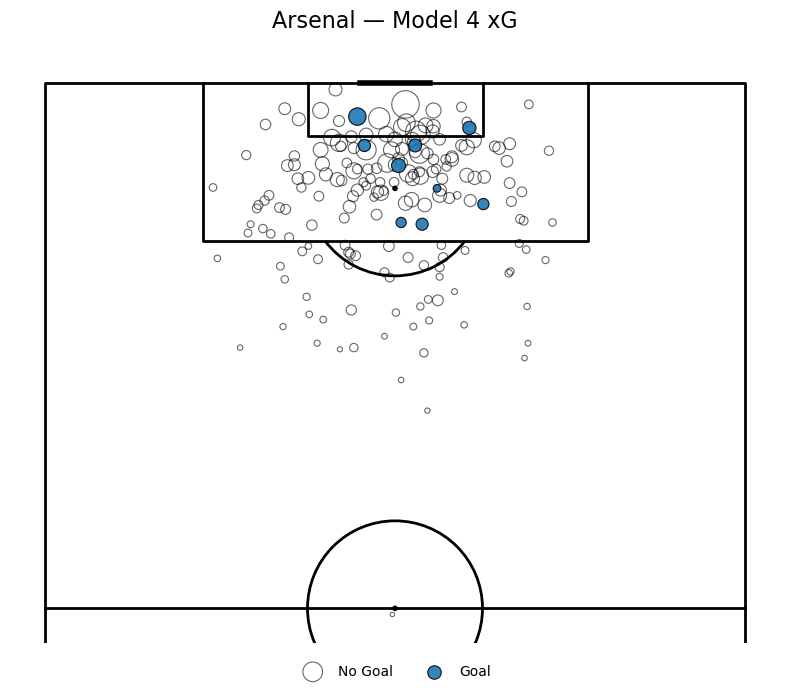

In [23]:
team_shots = test[
    test["team"] == "Arsenal"
]

plot_shot_map(
    team_shots,
    xg_column="xg_shot_characteristics",
    title="Arsenal — Model 4 xG",
    save_path="../../reports/figures/arsenal_shot_map.png"
)

(<Figure size 800x1000 with 1 Axes>,
 <Axes: title={'center': 'Match 3754300 — Model 4 xG'}>)

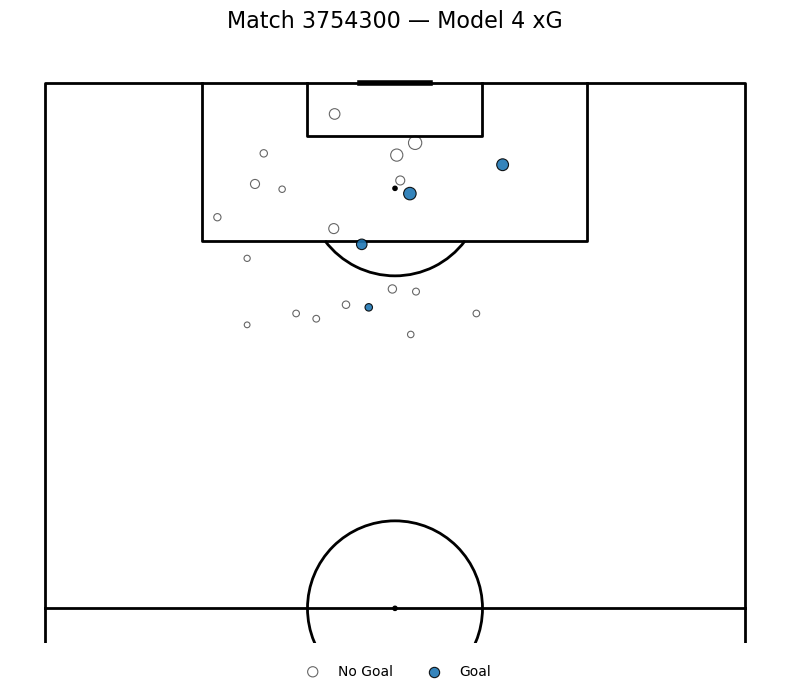

In [24]:
match_id = test["match_id"].iloc[0]

match_shots = test[
    test["match_id"] == match_id
]

plot_shot_map(
    match_shots,
    xg_column="xg_shot_characteristics",
    title=f"Match {match_id} — Model 4 xG"
)